# Crop Yield Prediction — Data Cleaning & Preprocessing

This notebook prepares the raw crop yield data for model training. The key steps are
removing the redundant index column, verifying data quality, one-hot encoding the two
categorical columns (`Area` and `Item`), and saving a cleaned CSV for the modelling notebook.

## 1. Imports, Load Raw Data & Import Utils

We load the raw CSV via `utils.load_data()`, which automatically drops the unnamed index column,
and then import the preprocessing utilities.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')

import sys, os
sys.path.insert(0, os.path.abspath('.'))
from utils import load_data, preprocess_data

sns.set_style('whitegrid')
%matplotlib inline

df = load_data('data/yield_df.csv')
print('Raw shape:', df.shape)
df.head()

Raw shape: (28242, 7)


,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


## 2. Missing Values & Duplicates

The EDA confirmed there are no missing values and no duplicate rows in this dataset.
We verify this explicitly here before proceeding.

In [2]:
print('Missing values per column:')
print(df.isnull().sum())
print()
print('Duplicate rows:', df.duplicated().sum())
print()
print('Columns:', df.columns.tolist())

Missing values per column:
Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64



Duplicate rows: 2310

Columns: ['Area', 'Item', 'Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']


In [3]:
# Show basic statistics for all columns
df.describe(include='all').round(2)

,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
count,28242,28242,28242.00,28242.00,28242.00,28242.00,28242.00
unique,101,10,NaN,NaN,NaN,NaN,NaN
top,India,Potatoes,NaN,NaN,NaN,NaN,NaN
freq,4048,4276,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,2001.54,77053.33,1149.06,37076.91,20.54
std,NaN,NaN,7.05,84956.61,709.81,59958.78,6.31
min,NaN,NaN,1990.00,50.00,51.00,0.04,1.30
25%,NaN,NaN,1995.00,19919.25,593.00,1702.00,16.70
50%,NaN,NaN,2001.00,38295.00,1083.00,17529.44,21.51
75%,NaN,NaN,2008.00,104676.75,1668.00,48687.88,26.00


## 3. One-Hot Encoding: Area and Item

**Strategy:** Both `Area` (101 countries) and `Item` (10 crop types) are nominal categorical
variables with no natural ordinal relationship. One-hot encoding is the correct approach here.
We use `drop_first=True` to avoid perfect multicollinearity (the dummy-variable trap).

- `Area` → 100 binary columns (one reference country dropped)
- `Item` → 9 binary columns (one reference crop dropped)

The resulting dataset will have `4 numeric + 100 + 9 = 113 feature columns` plus the target.

In [4]:
print('Before encoding:')
print(f'  Shape: {df.shape}')
print(f'  Area unique: {df["Area"].nunique()}')
print(f'  Item unique: {df["Item"].nunique()}')
print(f'  Item values: {sorted(df["Item"].unique())}')

df_clean = preprocess_data(df)

print()
print('After encoding:')
print(f'  Shape: {df_clean.shape}')
print(f'  Dtypes sample:')
print(df_clean.dtypes.value_counts())

Before encoding:
  Shape: (28242, 7)
  Area unique: 101
  Item unique: 10
  Item values: ['Cassava', 'Maize', 'Plantains and others', 'Potatoes', 'Rice, paddy', 'Sorghum', 'Soybeans', 'Sweet potatoes', 'Wheat', 'Yams']
  Dropped 2310 duplicate rows (kept 25932)



After encoding:
  Shape: (25932, 114)
  Dtypes sample:
int64      111
float64      3
Name: count, dtype: int64


In [5]:
# Show a snippet of the new dummy columns
area_cols = [c for c in df_clean.columns if c.startswith('Area_')]
item_cols = [c for c in df_clean.columns if c.startswith('Item_')]
print(f'Area dummy columns: {len(area_cols)} (e.g. {area_cols[:5]})')
print(f'Item dummy columns: {len(item_cols)} (e.g. {item_cols[:5]})')

Area dummy columns: 100 (e.g. ['Area_Algeria', 'Area_Angola', 'Area_Argentina', 'Area_Armenia', 'Area_Australia'])
Item dummy columns: 9 (e.g. ['Item_Maize', 'Item_Plantains and others', 'Item_Potatoes', 'Item_Rice, paddy', 'Item_Sorghum'])


## 4. Before / After Shape Comparison

A quick summary confirms the dimension change after encoding.

In [6]:
summary = pd.DataFrame({
    'Stage': ['Raw (after dropping index)', 'After one-hot encoding'],
    'Rows': [df.shape[0], df_clean.shape[0]],
    'Columns': [df.shape[1], df_clean.shape[1]],
})
print(summary.to_string(index=False))

                     Stage  Rows  Columns
Raw (after dropping index) 28242        7
    After one-hot encoding 25932      114


## 5. Feature Engineering Note

The four original numeric features (`average_rain_fall_mm_per_year`, `pesticides_tonnes`,
`avg_temp`, `Year`) are retained as-is. Because tree-based models (Random Forest, Gradient Boosting)
are scale-invariant, no log-transform is applied here; the StandardScaler in notebook 03 handles
scaling for linear and distance-based models.

A potential future enhancement would be to log-transform the highly right-skewed `pesticides_tonnes`
and the target `hg/ha_yield` for improved linear-model performance.

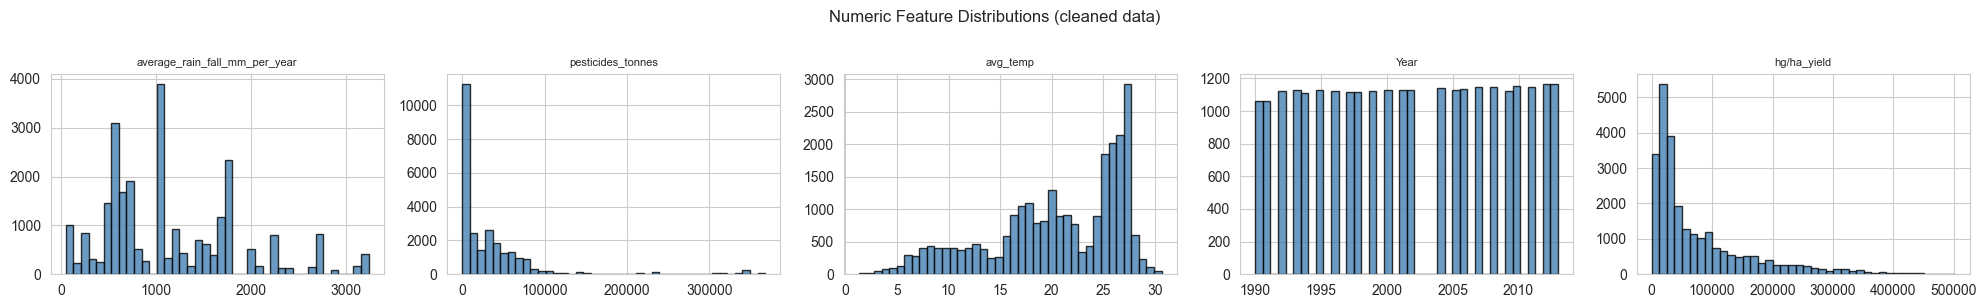

In [7]:
# Quick distribution plot of numeric features in cleaned dataframe
num_cols = ['average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp', 'Year', 'hg/ha_yield']
fig, axes = plt.subplots(1, 5, figsize=(20, 3))
for ax, col in zip(axes, num_cols):
    ax.hist(df_clean[col], bins=40, color='steelblue', edgecolor='black', alpha=0.8)
    ax.set_title(col, fontsize=8)
    ax.set_xlabel('')
plt.suptitle('Numeric Feature Distributions (cleaned data)', y=1.01)
plt.tight_layout()
plt.show()

## 6. Verify & Save Cleaned CSV

We verify that there are no remaining null values and then save the cleaned dataframe to
`data/crop_yield_cleaned.csv` for the model-building notebook.

In [8]:
print('Null check after cleaning:')
null_counts = df_clean.isnull().sum()
print(null_counts[null_counts > 0] if null_counts.sum() > 0 else '  No nulls found — all clear.')
print()
print('Final cleaned shape:', df_clean.shape)
print('Target column present:', 'hg/ha_yield' in df_clean.columns)

out_path = 'data/crop_yield_cleaned.csv'
df_clean.to_csv(out_path, index=False)
print(f'\nSaved to: {out_path}')

Null check after cleaning:


  No nulls found — all clear.

Final cleaned shape: (25932, 114)
Target column present: True



Saved to: data/crop_yield_cleaned.csv
